<a href="https://colab.research.google.com/github/JorgeEncinas/pytorch_ztm/blob/main/towards_data_science_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### What is Gradient Descent? - Implementing it
The code comes from [here](https://towardsdatascience.com/gradient-descent-unraveled-3274c895d12d-2/)

In [9]:
import numpy as np
import matplotlib.pyplot as plt

First it seems like they define an equation

In [5]:
def loss_surface(x): #x^4 + x^3 - 6x^2
  return np.power(x, 4) + np.power(x, 3) - 6*np.power(x,2)

def parabola_grad(x): #The first derivative. 4x^3 + 3x^2 - 12x
  return 4*np.power(x,3) + 3*np.power(x, 2) - 12*x

Now it seems like it's time for gradient descent...

In [4]:
x0 = np.random.uniform(-3, 3) # A random starting point
lr = 0.01 #A learning rate

In [7]:
x_list = [x0] #we will keep a list of the points we've "descended" to through Gradient Descent

## Gradient Descent

In [8]:
for i in range(100):
  x0 = x0 - (lr*parabola_grad(x0))
  x_list.append(x0) #Appending the point we descended into.

x_list = np.array(x_list)
y_list = loss_surface(x_list) # We should see the original function decrease, since we're looking for the lowest point in the convex function that Gradient Descent navigates

## Plotting

<ipython-input-11-1774771628>:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


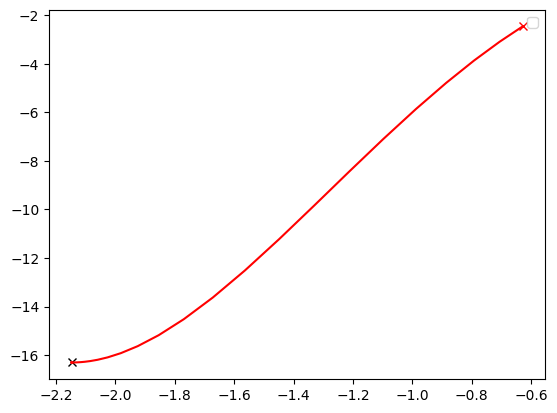

In [11]:
plt.plot(x_list[0],y_list[0],'rx');
plt.plot(x_list[-1],y_list[-1],'kx');
plt.plot(x_list,y_list,'r-');

### Gradient Descent in 2D

Let's see if we can follow this tutorial and implement this in 2D

In [17]:
import sympy as sp
from sympy import symbols, diff, lambdify
from mpl_toolkits import mplot3d

In [28]:
x = symbols('x')
y = symbols('y')

f1 = ((x-2)**2) + ((y-2)**2) + 5

f1x = diff(f1,x)
f1y = diff(f1,y)

f = lambdify([x,y], f1, 'numpy')

In [29]:
x_grid = np.linspace(-3, 3, 30)
y_grid = np.linspace(-3, 3, 30)
X, Y = np.meshgrid(x_grid, y_grid)

In [30]:
#Surface Function using the lambdify function
Z = f(X, Y)

Alright, I can't claim to understand entirely what was going on in the preceding blocks.

My guess is that it was a way of defining functions in a clean, easy manner. Then we applied it to our X, Y grid.

In [31]:
x0, y0 = (3, 3) #Starting point
xlist = [x0]
ylist = [y0]

In [32]:
lr = 0.001

## Performing Gradient Descent

In [33]:
for i in range(100):
  x0 -= ( lr*f1x.evalf(subs={x:x0, y:y0}) ) #Seems like our f1x, f1y are ways to easily calculate the gradient functions.
  y0 -= ( lr*f1y.evalf(subs={x:x0, y:y0}) )

  xlist.append(x0)
  ylist.append(y0)


xarr = np.array(xlist, dtype='float64')
yarr = np.array(ylist, dtype='float64')
zlist = list(f(xarr, yarr)) # I guess this must be an array created from the output of all of these x, y values we got.

## Plotting 2D Gradient Descent

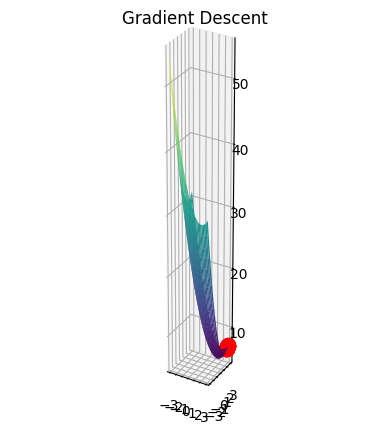

In [34]:
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z,
                rstride=1, cstride=1,
                cmap='viridis', edgecolor='none')

#ax.plot(xlist, ylist, zlist,
#        markerfacecolor='r',
#        markeredgecolor='r',
#        marker='o',
#        markersize=10,
#        alpha=0.6)
ax.plot(xlist, ylist, zlist, 'ro', markersize=10, alpha=0.6)
ax.set_title("Gradient Descent")
ax.set_aspect('equal')